<a href="https://colab.research.google.com/github/NataliaUrzagaste/se-ales-y-sistemas/blob/main/practico_3_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

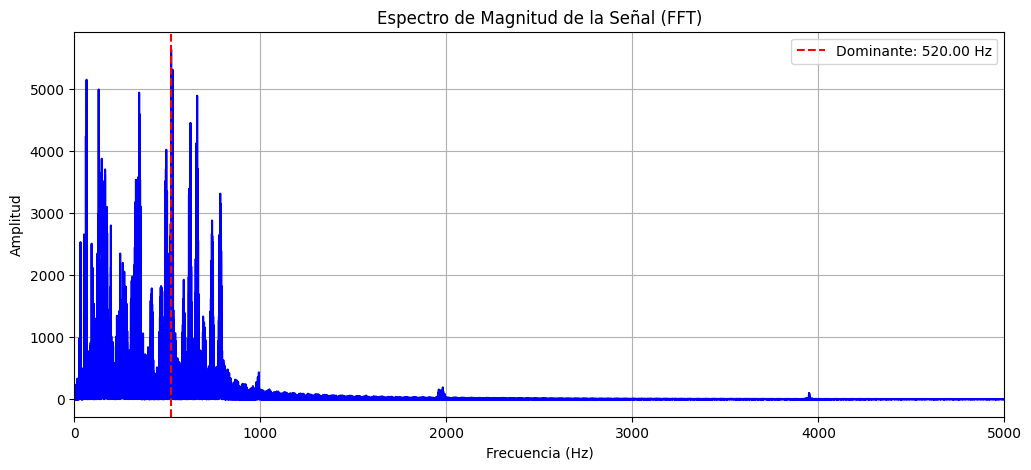

La frecuencia dominante calculada es: 520.00 Hz


In [ ]:
# EJERCICIO 1
import numpy as np
import librosa
import matplotlib.pyplot as plt

# 1. Cargar el audio
archivo = '/content/audio_con_ruido (3).wav'
y, sr = librosa.load(archivo)

# 2. Calcular la FFT
n = len(y)
frecuencias = np.fft.rfftfreq(n, d=1/sr)
fft_magnitud = np.abs(np.fft.rfft(y))

# 3. Encontrar la Frecuencia Dominante
indice_max = np.argmax(fft_magnitud)
f_dominante = frecuencias[indice_max]

# 4. Graficar el Espectro
plt.figure(figsize=(12, 5))
plt.plot(frecuencias, fft_magnitud, color='blue')
plt.title('Espectro de Magnitud de la Señal (FFT)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True)

# Marcamos la frecuencia dominante en la gráfica
plt.axvline(x=f_dominante, color='red', linestyle='--', label=f'Dominante: {f_dominante:.2f} Hz')
plt.legend()
plt.xlim(0, 5000)
plt.show()

print(f"La frecuencia dominante calculada es: {f_dominante:.2f} Hz")

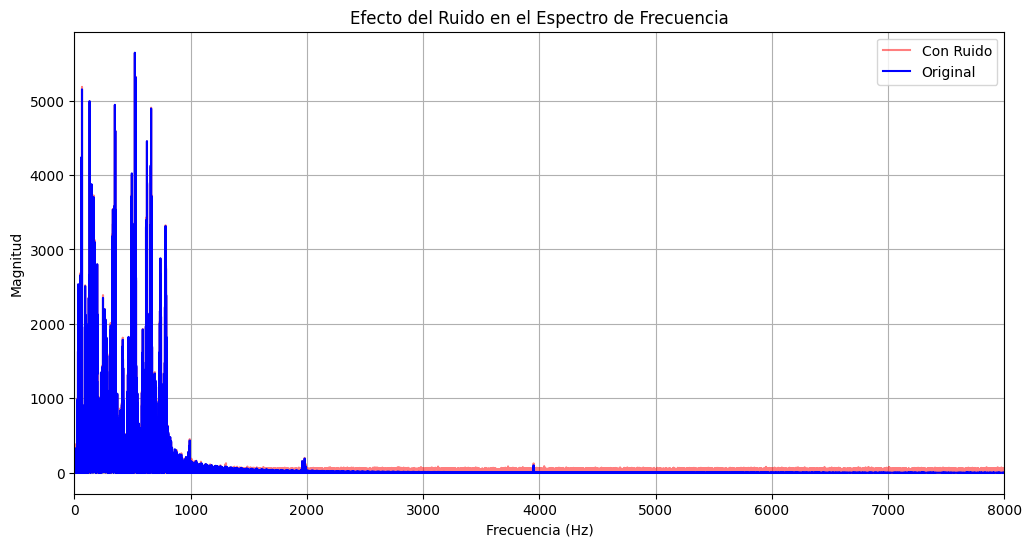

In [ ]:
# EJERCICIO 2
import numpy as np
import librosa
import matplotlib.pyplot as plt

# 1. Cargar señal original
archivo = '/content/audio_con_ruido (3).wav'
y, sr = librosa.load(archivo)
n = len(y)
frecuencias = np.fft.rfftfreq(n, d=1/sr)

# 2. Generar ruido blanco y añadirlo
nivel_ruido = 0.02
ruido = np.random.normal(0, nivel_ruido, n)
y_ruido = y + ruido

# 3. Calcular FFT de ambas señales
fft_original = np.abs(np.fft.rfft(y))
fft_con_ruido = np.abs(np.fft.rfft(y_ruido))

# 4. Graficar comparación
plt.figure(figsize=(12, 6))
plt.plot(frecuencias, fft_con_ruido, color='red', alpha=0.5, label='Con Ruido')
plt.plot(frecuencias, fft_original, color='blue', label='Original')
plt.title('Efecto del Ruido en el Espectro de Frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.legend()
plt.xlim(0, 8000)
plt.grid(True)
plt.show()

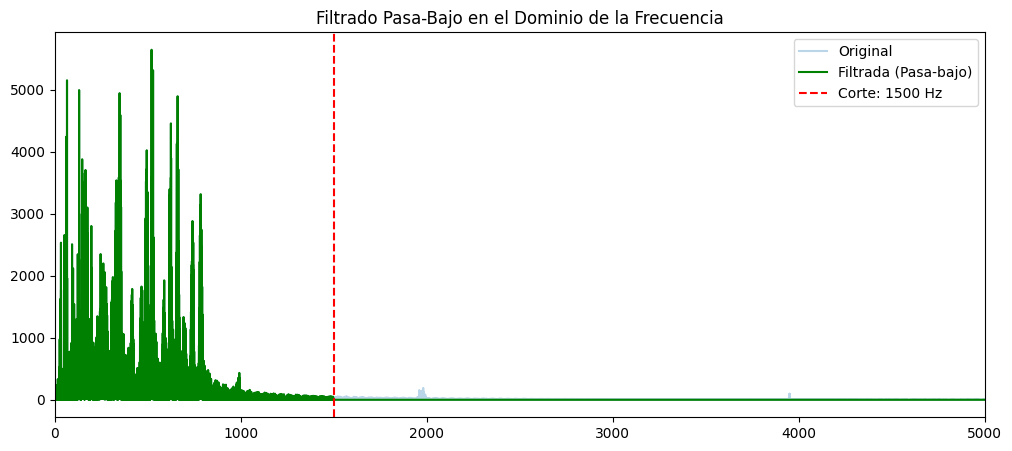

La frecuencia dominante después del filtrado es: 520.00 Hz


In [ ]:
#EJERCICIO 3
import numpy as np
import librosa
import matplotlib.pyplot as plt

# 1. Cargar la señal original
archivo = '/content/audio_con_ruido (3).wav'
y, sr = librosa.load(archivo)
n = len(y)

# 2. Transformar al dominio de la frecuencia
frecuencias = np.fft.rfftfreq(n, d=1/sr)
fft_original = np.fft.rfft(y)

# 3. Aplicar Filtro Pasa-Bajo Ideal
f_corte = 1500
fft_filtrada = fft_original.copy()
fft_filtrada[frecuencias > f_corte] = 0

# 4. Volver al dominio del tiempo
y_filtrada = np.fft.irfft(fft_filtrada)

# 5. Calcular nueva frecuencia dominante
idx_max = np.argmax(np.abs(fft_filtrada))
f_dominante = frecuencias[idx_max]

# 6. Gráficas
plt.figure(figsize=(12, 5))
plt.plot(frecuencias, np.abs(fft_original), label='Original', alpha=0.3)
plt.plot(frecuencias, np.abs(fft_filtrada), label='Filtrada (Pasa-bajo)', color='green')
plt.axvline(x=f_corte, color='red', linestyle='--', label=f'Corte: {f_corte} Hz')
plt.title('Filtrado Pasa-Bajo en el Dominio de la Frecuencia')
plt.legend()
plt.xlim(0, 5000)
plt.show()

print(f"La frecuencia dominante después del filtrado es: {f_dominante:.2f} Hz")

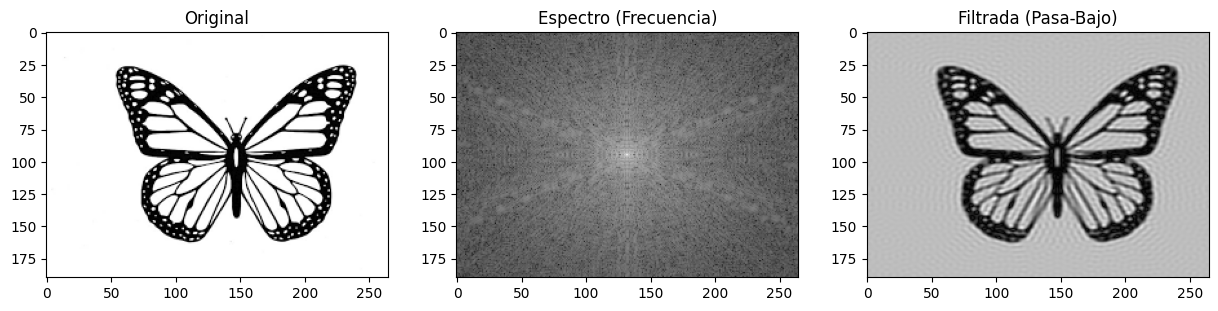

In [ ]:
# EJERCICIO 4
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Cargar imagen en escala de grises
img = cv2.imread('/content/images.png', 0)

# 2. Transformada de Fourier 2D
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
espectro_amplitud = 20 * np.log(np.abs(fshift))

# 3. Crear Filtro Pasa-Bajo
filas, cols = img.shape
centro_f, centro_c = filas // 2 , cols // 2
radio = 50 # Ajusta para ver más o menos detalle
mascara = np.zeros((filas, cols), np.uint8)
cv2.circle(mascara, (centro_c, centro_f), radio, 1, thickness=-1)

# 4. Aplicar máscara y volver al dominio espacial
f_filtrado = fshift * mascara
f_ishift = np.fft.ifftshift(f_filtrado)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# 5. Visualización
plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(132), plt.imshow(espectro_amplitud, cmap='gray'), plt.title('Espectro (Frecuencia)')
plt.subplot(133), plt.imshow(img_back, cmap='gray'), plt.title('Filtrada (Pasa-Bajo)')
plt.show()